# 데이터분석

In [1]:
!pwd

/home/jovyan/work


In [27]:
# https://data.seoul.go.kr/dataList/10956/S/2/datasetView.do#
import pandas as pd
file_path = './dataset/청소년정신건강20260604.csv'
df = pd.read_csv(file_path)
df

,시점,스트레스 인지율,스트레스 인지율.1,스트레스 인지율.2,우울감 경험률,우울감 경험률.1,우울감 경험률.2,자살 생각률,자살 생각률.1,자살 생각률.2
0,시점,전체,남학생,여학생,전체,남학생,여학생,전체,남학생,여학생
1,2025,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [28]:
new_name=['시점','스트레스','스트레스남학생','스트레스여학생','우울감경험율','우울남학생','우울여학생','자살생각률','자살남학생','자살여학생']
df.columns = new_name
df

,시점,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
0,시점,전체,남학생,여학생,전체,남학생,여학생,전체,남학생,여학생
1,2025,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [29]:
ori = df.iloc[1:,1:]
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2


In [30]:
# 2번 인덱스를 생성, 토탈에서 값을 뺀값
ori.loc[2] = 100 - ori.loc[1,:].astype('float')
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2
2,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8


In [31]:
ori['응답'] = ['그렇다','아니다']
ori

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생,응답
1,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2,그렇다
2,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8,아니다


In [44]:
data = ori.set_index('응답')
data

,스트레스,스트레스남학생,스트레스여학생,우울감경험율,우울남학생,우울여학생,자살생각률,자살남학생,자살여학생
응답,,,,,,,,,
그렇다,42.6,34.0,51.8,26.8,23.5,30.3,12.7,9.4,16.2
아니다,57.4,66.0,48.2,73.2,76.5,69.7,87.3,90.6,83.8


Text(0.2, 0.4, '한글')

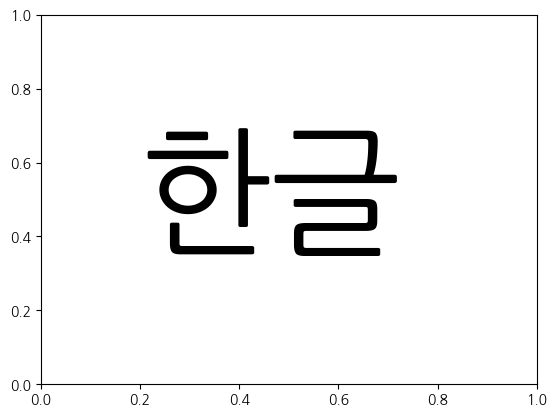

In [45]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [46]:
#데이터 타입변경
data['스트레스'] = data['스트레스'].astype('float')

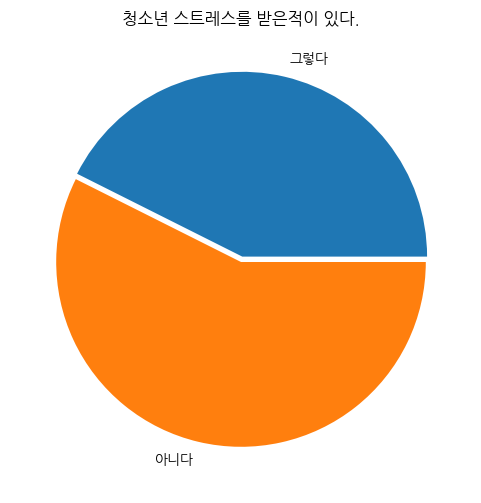

In [49]:
# data['스트레스'].plot.pie()
plt.figure(figsize=(6,6))
plt.pie(data['스트레스'], labels=data.index, explode=[0.03,0])
plt.title('청소년 스트레스를 받은적이 있다.')
plt.show()

In [50]:
data.dtypes

스트레스       float64
스트레스남학생     object
스트레스여학생     object
우울감경험율      object
우울남학생       object
우울여학생       object
자살생각률       object
자살남학생       object
자살여학생       object
dtype: object

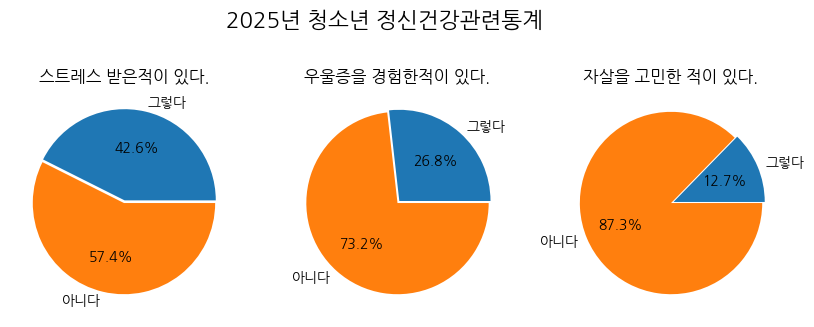

In [56]:

# 권장
fig , ax = plt.subplots(1,3, figsize=(10,4))
# data['스트레스'].plot.pie(ax=ax[0],autopct="%.1f%%", explode=[0.03,0]).set_ylabel('')
# data['우울감경험율'].astype('float').plot.pie(ax=ax[1],autopct="%.1f%%", explode=[0.03,0]).set_ylabel('')
# data['자살생각률'].astype('float').plot.pie(ax=ax[2],autopct="%.1f%%", explode=[0.03,0]).set_ylabel('')

ax[0].pie(data['스트레스'],labels= data.index, autopct="%.1f%%", explode=[0.03,0])
ax[0].set_title('스트레스 받은적이 있다.')
ax[1].pie(data['우울감경험율'], labels= data.index,autopct="%.1f%%", explode=[0.03,0])
ax[1].set_title('우울증을 경험한적이 있다.')
ax[2].pie(data['자살생각률'], labels= data.index,autopct="%.1f%%", explode=[0.03,0])
ax[2].set_title('자살을 고민한 적이 있다.')

plt.suptitle('2025년 청소년 정신건강관련통계', fontsize=16)
plt.show()